In [2]:
library(tidyverse)

freq_data <- read_csv("D:/my_projects/AD/freMTPL2freq.csv", show_col_types = FALSE)
sev_data <- read_csv("D:/my_projects/AD/freMTPL2sev.csv", show_col_types = FALSE)

sev_data_clean <- sev_data %>% distinct()

sev_aggregated <- sev_data_clean %>%
  group_by(IDpol) %>%
  summarise(Total_Claim_Amount = sum(ClaimAmount), .groups = 'drop')

full_data <- freq_data %>%
  left_join(sev_aggregated, by = "IDpol") %>%
  mutate(
    Total_Claim_Amount = replace_na(Total_Claim_Amount, 0),
    Exposure = if_else(Exposure > 1, 1, Exposure),
    VehBrand = as.factor(VehBrand),
    VehGas = as.factor(VehGas),
    Region = as.factor(Region),
    Area = as.factor(Area)
  ) %>%
  filter(!(ClaimNb == 0 & Total_Claim_Amount > 0)) %>%
  filter(!(ClaimNb > 0 & Total_Claim_Amount == 0))

claims_only <- full_data %>% filter(Total_Claim_Amount > 0)

claims_classified <- claims_only %>%
  mutate(
    Claim_Type = if_else(round(Total_Claim_Amount) %in% c(1204, 1128, 1172), 
                         "Фіксовані суми (Аномалія)", 
                         "Індивідуальні аварії (Норма)")
  )

age_sev <- claims_only %>%
  group_by(DrivAge) %>%
  summarise(
    Avg_Claim = mean(Total_Claim_Amount),
    Count = n(),
    .groups = 'drop'
  ) %>%
  filter(Count > 5)

individual_claims <- claims_classified %>% 
  filter(Claim_Type == "Індивідуальні аварії (Норма)")

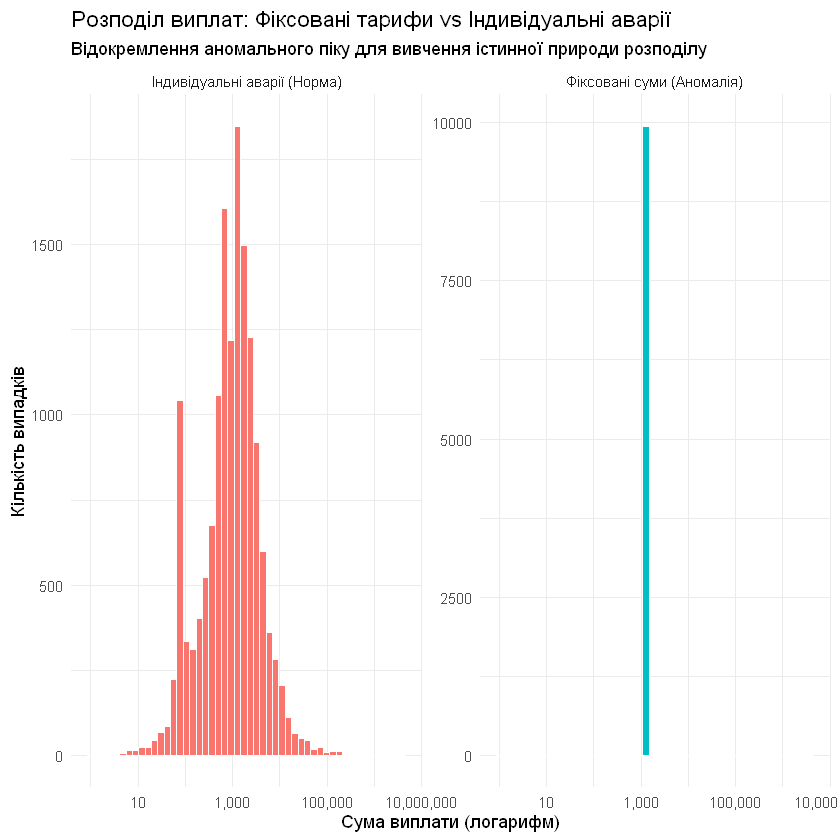

In [3]:
claims_classified <- claims_only %>%
  mutate(
    Claim_Type = if_else(round(Total_Claim_Amount) %in% c(1204, 1128, 1172), 
                         "Фіксовані суми (Аномалія)", 
                         "Індивідуальні аварії (Норма)")
  )

ggplot(claims_classified, aes(x = Total_Claim_Amount, fill = Claim_Type)) +
  geom_histogram(color = "white", bins = 50) +
  scale_x_log10(labels = scales::comma) +
  facet_wrap(~Claim_Type, scales = "free_y") +
  labs(
    title = "Розподіл виплат: Фіксовані тарифи vs Індивідуальні аварії",
    subtitle = "Відокремлення аномального піку для вивчення істинної природи розподілу",
    x = "Сума виплати (логарифм)",
    y = "Кількість випадків"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

In [4]:
top_claims <- claims_only %>%
  count(Total_Claim_Amount, sort = TRUE) %>%
  head(10)

print(top_claims)

# A tibble: 10 × 2
   Total_Claim_Amount     n
                <dbl> <int>
 1              1204   4412
 2              1128.  2826
 3              1172   1925
 4              1128    757
 5               602    374
 6              1320    148
 7               586     89
 8               564.    87
 9              3204     85
10               556.    80


In [5]:
tariff_families <- claims_only %>%
  count(Total_Claim_Amount, sort = TRUE) %>%
  head(20) %>%
  mutate(
    Tariff_Family = case_when(
      Total_Claim_Amount %in% c(602, 1204, 2408) ~ "Сім'я 1204 (Тариф А: 602/1204/2408)",
      Total_Claim_Amount %in% c(564.06, 1128.12, 1128) ~ "Сім'я 1128 (Тариф Б: 564/1128)",
      Total_Claim_Amount %in% c(586, 1172) ~ "Сім'я 1172 (Тариф В: 586/1172)",
      TRUE ~ "Інші / Індивідуальні"
    )
  ) %>%
  filter(Tariff_Family != "Інші / Індивідуальні") %>%
  arrange(Tariff_Family, Total_Claim_Amount)

print(tariff_families)

# A tibble: 8 × 3
  Total_Claim_Amount     n Tariff_Family                      
               <dbl> <int> <chr>                              
1               564.    87 Сім'я 1128 (Тариф Б: 564/1128)     
2              1128    757 Сім'я 1128 (Тариф Б: 564/1128)     
3              1128.  2826 Сім'я 1128 (Тариф Б: 564/1128)     
4               586     89 Сім'я 1172 (Тариф В: 586/1172)     
5              1172   1925 Сім'я 1172 (Тариф В: 586/1172)     
6               602    374 Сім'я 1204 (Тариф А: 602/1204/2408)
7              1204   4412 Сім'я 1204 (Тариф А: 602/1204/2408)
8              2408     40 Сім'я 1204 (Тариф А: 602/1204/2408)


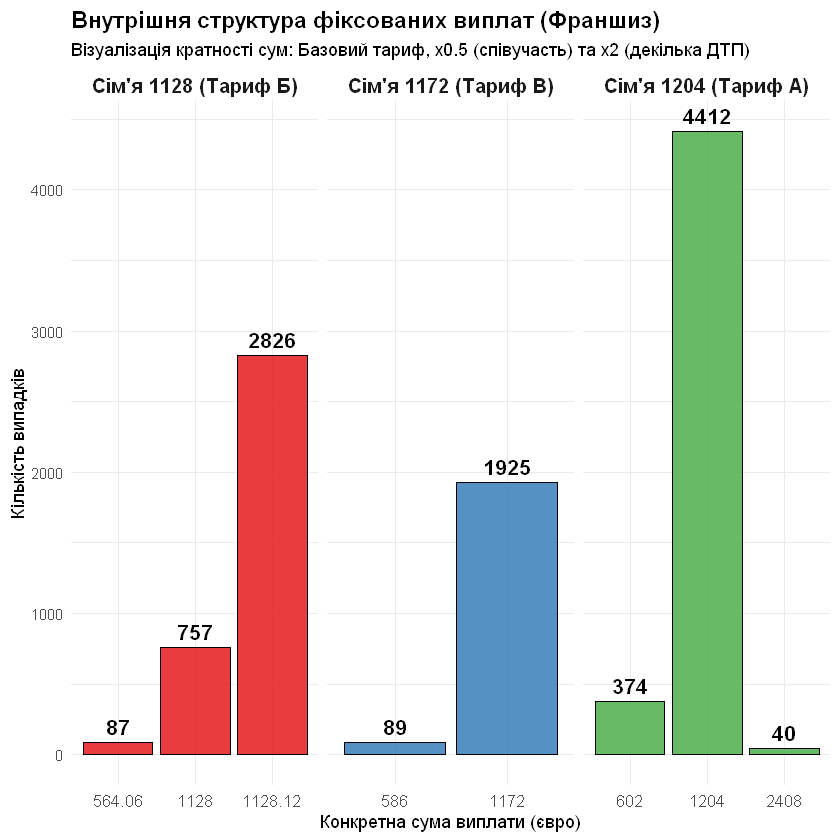

In [6]:
anomalies_grouped <- claims_only %>%
  filter(Total_Claim_Amount %in% c(602, 1204, 2408, 564.06, 1128, 1128.12, 586, 1172)) %>%
  mutate(
    Exact_Amount = as.factor(Total_Claim_Amount),
    Tariff_Family = case_when(
      Total_Claim_Amount %in% c(602, 1204, 2408) ~ "Сім'я 1204 (Тариф А)",
      Total_Claim_Amount %in% c(564.06, 1128.12, 1128) ~ "Сім'я 1128 (Тариф Б)",
      Total_Claim_Amount %in% c(586, 1172) ~ "Сім'я 1172 (Тариф В)"
    )
  )

ggplot(anomalies_grouped, aes(x = Exact_Amount, fill = Tariff_Family)) +
  geom_bar(color = "black", alpha = 0.85) +
  geom_text(stat = 'count', aes(label = after_stat(count)), vjust = -0.5, size = 4.5, fontface = "bold") +
  facet_wrap(~Tariff_Family, scales = "free_x") + 
  scale_fill_brewer(palette = "Set1") +
  labs(
    title = "Внутрішня структура фіксованих виплат (Франшиз)",
    subtitle = "Візуалізація кратності сум: Базовий тариф, х0.5 (співучасть) та х2 (декілька ДТП)",
    x = "Конкретна сума виплати (євро)",
    y = "Кількість випадків"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 12, face = "bold"),
    plot.title = element_text(size = 14, face = "bold"),
    axis.text.x = element_text(size = 10)
  )

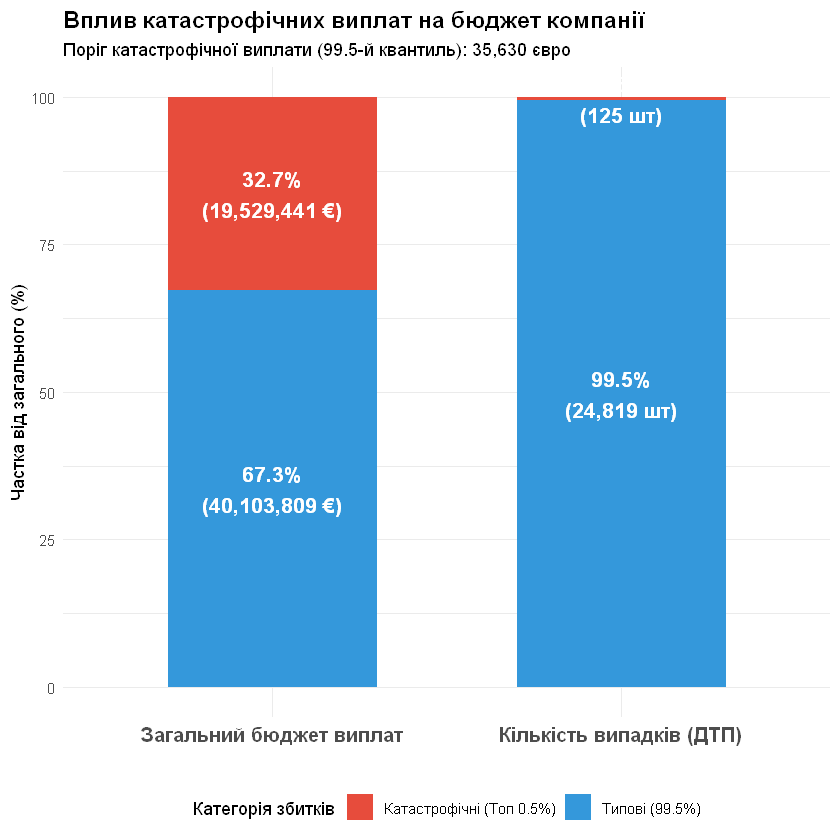

In [9]:
library(tidyr)
library(scales) 
threshold_995 <- quantile(claims_only$Total_Claim_Amount, 0.995)

catastrophe_analysis <- claims_only %>%
  mutate(
    Severity_Category = if_else(Total_Claim_Amount > threshold_995, 
                                "Катастрофічні (Топ 0.5%)", 
                                "Типові (99.5%)")
  )

catastrophe_summary <- catastrophe_analysis %>%
  group_by(Severity_Category) %>%
  summarise(
    Count = n(),
    Total_Money = sum(Total_Claim_Amount)
  ) %>%
  mutate(
    Pct_Count = Count / sum(Count) * 100,
    Pct_Money = Total_Money / sum(Total_Money) * 100
  )

catastrophe_long <- catastrophe_summary %>%
  pivot_longer(
    cols = c(Pct_Count, Pct_Money), 
    names_to = "Metric", 
    values_to = "Percentage"
  ) %>%
  mutate(
    Metric_Name = if_else(Metric == "Pct_Count", 
                          "Кількість випадків (ДТП)", 
                          "Загальний бюджет виплат"),
    Absolute_Value = if_else(Metric == "Pct_Count", 
                             paste0(comma(Count), " шт"), 
                             paste0(comma(round(Total_Money)), " €")),
    Final_Label = sprintf("%.1f%%\n(%s)", Percentage, Absolute_Value)
  )

ggplot(catastrophe_long, aes(x = Metric_Name, y = Percentage, fill = Severity_Category)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = Final_Label), 
            position = position_stack(vjust = 0.5), 
            size = 4.5, color = "white", fontface = "bold") +
  scale_fill_manual(values = c("Катастрофічні (Топ 0.5%)" = "#e74c3c", "Типові (99.5%)" = "#3498db")) +
  labs(
    title = "Вплив катастрофічних виплат на бюджет компанії",
    subtitle = paste0("Поріг катастрофічної виплати (99.5-й квантиль): ", comma(round(threshold_995)), " євро"),
    x = "",
    y = "Частка від загального (%)",
    fill = "Категорія збитків"
  ) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    plot.title = element_text(size = 14, face = "bold"),
    axis.text.x = element_text(size = 12, face = "bold")
  )

Ймовірність збитку > 10,000 євро: 2.2% 
Ймовірність збитку > 50,000 євро: 0.36% 


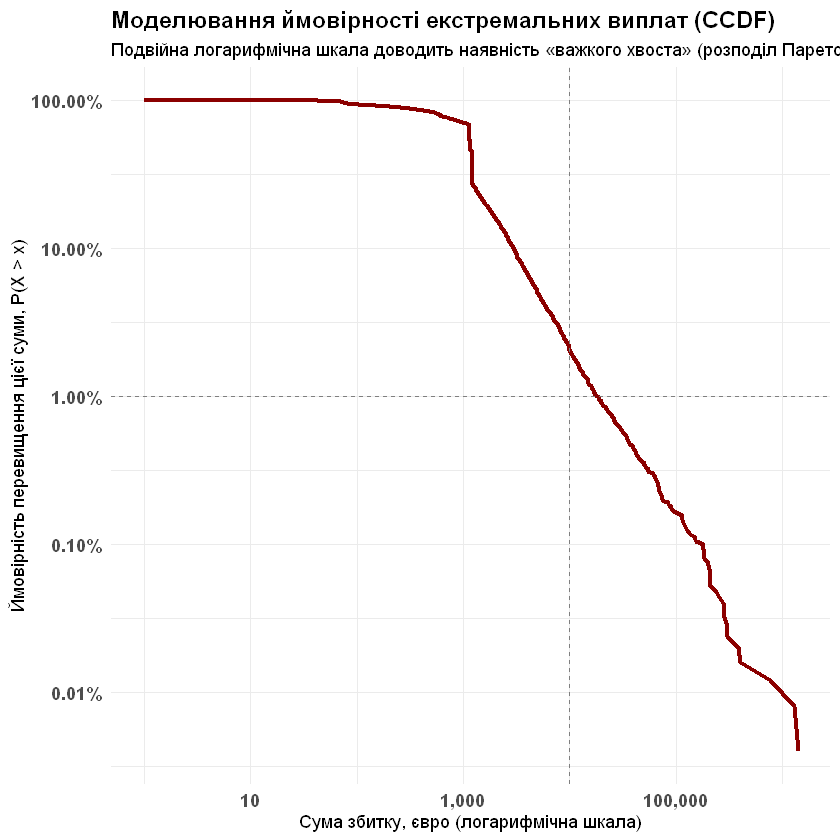

In [10]:
library(dplyr)
library(ggplot2)
library(scales)

prob_model <- claims_only %>%
  filter(Total_Claim_Amount > 0) %>%
  arrange(Total_Claim_Amount) %>%
  mutate(
    CDF = row_number() / n(),
    Prob_Exceed = 1 - CDF
  ) %>%
  filter(Prob_Exceed > 0)

prob_10k <- prob_model %>% filter(Total_Claim_Amount >= 10000) %>% pull(Prob_Exceed) %>% max()
prob_50k <- prob_model %>% filter(Total_Claim_Amount >= 50000) %>% pull(Prob_Exceed) %>% max()

cat("Ймовірність збитку > 10,000 євро:", percent(prob_10k, accuracy = 0.1), "\n")
cat("Ймовірність збитку > 50,000 євро:", percent(prob_50k, accuracy = 0.01), "\n")

ggplot(prob_model, aes(x = Total_Claim_Amount, y = Prob_Exceed)) +
  geom_line(color = "darkred", size = 1.2) +
  scale_x_log10(labels = comma) +
  scale_y_log10(labels = percent) +
  geom_hline(yintercept = 0.01, linetype = "dashed", color = "gray50") +
  geom_vline(xintercept = 10000, linetype = "dashed", color = "gray50") +
  labs(
    title = "Моделювання ймовірності екстремальних виплат (CCDF)",
    subtitle = "Подвійна логарифмічна шкала доводить наявність «важкого хвоста» (розподіл Парето)",
    x = "Сума збитку, євро (логарифмічна шкала)",
    y = "Ймовірність перевищення цієї суми, P(X > x)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 11, face = "bold")
  )